In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dropout,
    LSTM,
    Dense,
)
from tensorflow.keras.utils import to_categorical

print("--- All libraries imported successfully. ---")

--- All libraries imported successfully. ---


In [8]:
def plot_history(history):
    """Plots the model's training and validation accuracy and loss."""
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

print("--- plot_history() function defined. ---")

--- plot_history() function defined. ---


In [10]:
print("\n--- Loading and Preprocessing Training Data (Binary) ---")

try:
    df_train = pd.read_csv(r"C:\Users\tanma\Desktop\Major Project\OneDrive_2025-08-27\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv")
except FileNotFoundError:
    print("Error: 'UNSW_NB15_training-set.csv' not found.")
    # In a notebook, just stop here
else:
    # Drop 'id' and the multi-class 'attack_cat' column
    df_train = df_train.drop(["id", "attack_cat"], axis=1)
    df_train["service"] = df_train["service"].replace("-", "unknown")

    # Identify categorical, numerical, and target features
    categorical_cols = ["proto", "service", "state"]
    target_col = "label"  # Binary target
    numerical_cols = [
        col for col in df_train.columns if col not in categorical_cols + [target_col]
    ]

    # --- Feature Engineering (Training Set) ---
    df_train_categorical = pd.get_dummies(df_train[categorical_cols], dtype=int)

    # Create and fit the scaler
    scaler = MinMaxScaler()
    df_train_numerical = pd.DataFrame(
        scaler.fit_transform(df_train[numerical_cols]), columns=numerical_cols
    )

    # Combine processed features
    X = pd.concat([df_train_numerical, df_train_categorical], axis=1)

    # Get Target Variable (Binary)
    y = df_train[target_col].values

    print(f"Total features after preprocessing: {X.shape[1]}")
    print(f"Target 'y' shape: {y.shape}")


--- Loading and Preprocessing Training Data (Binary) ---
Total features after preprocessing: 194
Target 'y' shape: (175341,)


In [11]:
print("\n--- Splitting and Reshaping Training Data ---")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape data for CNN-LSTM: (samples, timesteps, features)
# Your model expects: (samples, 1, n_features)
n_features = X_train.shape[1]
X_train_reshaped = X_train.values.reshape((X_train.shape[0], 1, n_features))
X_val_reshaped = X_val.values.reshape((X_val.shape[0], 1, n_features))

print(f"Training data shape: {X_train_reshaped.shape}")
print(f"Validation data shape: {X_val_reshaped.shape}")


--- Splitting and Reshaping Training Data ---
Training data shape: (140272, 1, 194)
Validation data shape: (35069, 1, 194)


In [12]:
print("\n--- Building Model Architecture (Hybrid CNN-LSTM) ---")

INPUT_SHAPE = (1, n_features) # (timesteps, features)
NUM_CLASSES = 1 # Binary classification (Sigmoid output)

model = Sequential()

# CNN Feature Extraction
model.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPooling1D(pool_size=1))
model.add(Dropout(0.2))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(MaxPooling1D(pool_size=1))
model.add(Dropout(0.2))
model.add(Conv1D(filters=256, kernel_size=1, activation='relu'))
model.add(MaxPooling1D(pool_size=1))

# LSTM Sequence Modeling
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Classification Block
model.add(Dense(64, activation='relu'))
model.add(Dense(NUM_CLASSES, activation='sigmoid')) # Sigmoid for binary

# Compile the model
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

model.summary()


--- Building Model Architecture (Hybrid CNN-LSTM) ---


D:\SOUL SYSTEM\Software\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │        12,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,945 (1.20 MB)

 Trainable params: 314,945 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("\n--- Training Model ---")
print("This may take several minutes...")

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train_reshaped,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_reshaped, y_val),
    verbose=1,
)

print("\nTraining complete.")


--- Training Model ---
This may take several minutes...
Epoch 1/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9036 - loss: 0.2147 - val_accuracy: 0.9351 - val_loss: 0.1271
Epoch 2/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9358 - loss: 0.1299 - val_accuracy: 0.9405 - val_loss: 0.1205
Epoch 3/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9368 - loss: 0.1259 - val_accuracy: 0.9395 - val_loss: 0.1190
Epoch 4/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9381 - loss: 0.1238 - val_accuracy: 0.9425 - val_loss: 0.1192
Epoch 5/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9383 - loss: 0.1227 - val_accuracy: 0.9420 - val_loss: 0.1196
Epoch 6/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9395 - loss: 0.1213 - val_accuracy: 0.9425 - val_loss: 0.1186
Epoch 7/20
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9399 - loss: 0.1203 - val_accuracy: 0.9428 - val_loss: 0.1164
Epoch 8/20
2192/2192 ━━━━━


--- Plotting Training History ---


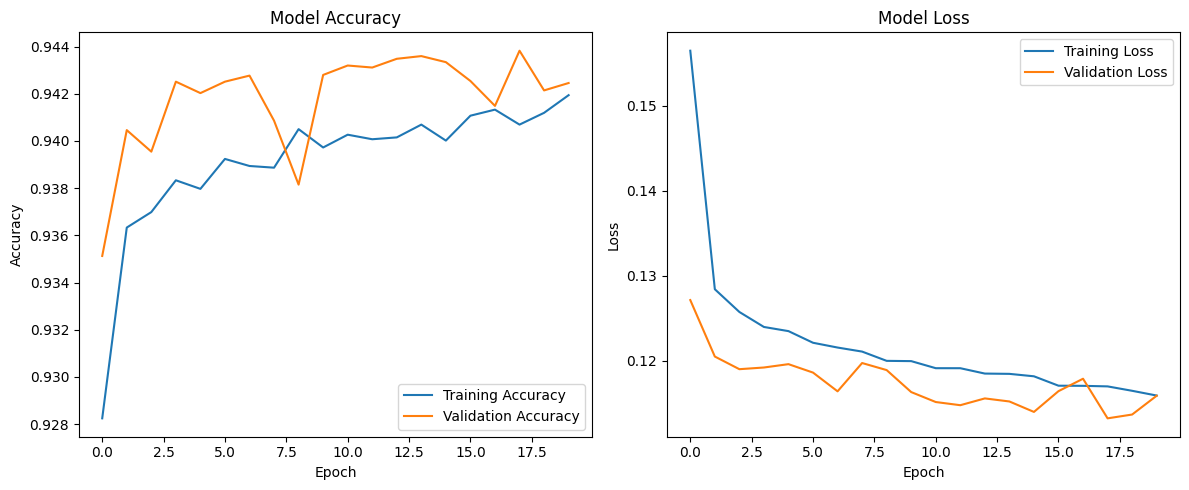

In [14]:
print("\n--- Plotting Training History ---")
plot_history(history)

In [15]:
print("\n--- Evaluating Model on Test Set ---")

try:
    df_test = pd.read_csv(r"C:\Users\tanma\Desktop\Major Project\OneDrive_2025-08-27\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv")
except FileNotFoundError:
    print("Error: 'UNSW_NB15_testing-set.csv' not found.")
else:
    # Preprocess Test Data (using FITTED scaler)
    df_test = df_test.drop(["id", "attack_cat"], axis=1)
    df_test["service"] = df_test["service"].replace("-", "unknown")

    # Define columns (needed if running this cell independently)
    target_col = "label"
    categorical_cols = ["proto", "service", "state"]
    numerical_cols = [
        col for col in df_train.columns if col not in categorical_cols + [target_col]
    ]

    # Separate features and target
    X_test_raw = df_test.drop(target_col, axis=1)
    y_test = df_test[target_col].values # This is our y_true

    # 1. Scale Numerical (use 'transform')
    df_test_numerical = pd.DataFrame(
        scaler.transform(X_test_raw[numerical_cols]), columns=numerical_cols
    )

    # 2. One-Hot Encode Categorical
    df_test_categorical = pd.get_dummies(
        X_test_raw[categorical_cols], dtype=int
    )

    # 3. Combine
    X_test_processed = pd.concat(
        [df_test_numerical, df_test_categorical], axis=1
    )

    # 4. CRITICAL: Align columns with the training data
    X_test_aligned = X_test_processed.reindex(columns=X.columns).fillna(0)

    print("Test data preprocessed successfully.")


--- Evaluating Model on Test Set ---
Test data preprocessed successfully.


In [16]:
print("\n--- Reshaping and Evaluating Test Data ---")

# Reshape test data to (samples, 1, n_features)
X_test_reshaped = X_test_aligned.values.reshape(
    (X_test_aligned.shape[0], 1, n_features)
)

print(f"Test data shape: {X_test_reshaped.shape}")

# Evaluate the model
loss, accuracy = model.evaluate(X_test_reshaped, y_test, verbose=0)

print("\n--- Model Test Results ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


--- Reshaping and Evaluating Test Data ---
Test data shape: (175341, 1, 194)

--- Model Test Results ---
Test Loss: 0.1144
Test Accuracy: 94.29%



--- Generating Final Reports ---
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.91      0.91      0.91     56000
  Attack (1)       0.96      0.96      0.96    119341

    accuracy                           0.94    175341
   macro avg       0.93      0.93      0.93    175341
weighted avg       0.94      0.94      0.94    175341


--- Confusion Matrix ---


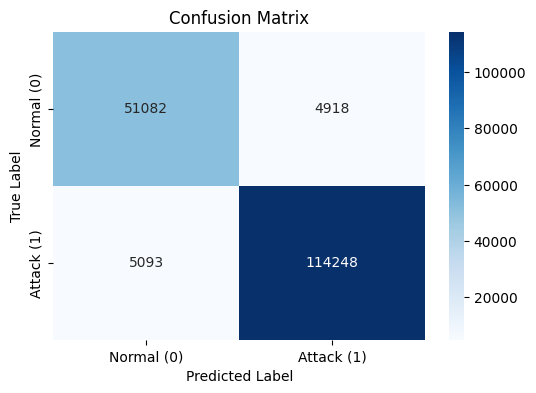


--- Process Finished ---


In [17]:
print("\n--- Generating Final Reports ---")

# Get model predictions (probabilities)
y_pred_probs = model.predict(X_test_reshaped)

# Convert probabilities to binary classes (0 or 1)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

# Use the simple y_test as the true classes
y_true_classes = y_test

# Define target names for the report
target_names = ["Normal (0)", "Attack (1)"]

# 1. Classification Report
print("\n--- Classification Report ---")
print(
    classification_report(
        y_true_classes, y_pred_classes, target_names=target_names
    )
)

# 2. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

print("\n--- Process Finished ---")